# train_lgbm_pattern_v3.ipynb
**LightGBM** — Pattern model, batch-by-batch

**Runs from:** `backend/model training/`

In [1]:
import os, pickle, time, warnings, gc, glob, tempfile
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore'); sns.set_theme(style='darkgrid')

MODEL_NAME='lgbm_pattern'; MODEL_DISPLAY='LightGBM Pattern'
DATA_DIR='../data generation/data'
PATTERN_DIR=f'{DATA_DIR}/pattern_features'; SCALER_DIR=f'{DATA_DIR}/scalers'
MODEL_DIR=f'../models/{MODEL_NAME}'; os.makedirs(MODEL_DIR, exist_ok=True)

with open(f'{PATTERN_DIR}/pattern_meta.pkl','rb') as f: meta=pickle.load(f)
with open(f'{SCALER_DIR}/scaler_pattern_ttr.pkl','rb') as f: scaler_ttr=pickle.load(f)
with open(f'{SCALER_DIR}/scaler_pattern_cong.pkl','rb') as f: scaler_cong=pickle.load(f)
FEATURES=meta['pattern_features']; N_EDGES=meta['n_edges']
FEATURES_IDX=['edge_idx']+FEATURES

batch_files=sorted(glob.glob(f'{PATTERN_DIR}/batch_*.parquet'))
print(f'Features: {len(FEATURES)}, Batches: {len(batch_files)}, Edges: {N_EDGES:,}')

Features: 63, Batches: 30, Edges: 145,265


In [2]:
# ── Load train+val data with float32 + memmap to stay within 8GB RAM ──────────
# FIX: original code used float64 (7.48 GB > 8GB RAM → MemoryError)
# Strategy: count rows first, allocate float32 memmap on disk, fill batch-by-batch
print('Pass 1: counting rows...')
n_tr, n_vl = 0, 0
for bf in batch_files:
    df = pd.read_parquet(bf, columns=['split'])
    n_tr += (df['split']=='train').sum()
    n_vl += (df['split']=='val').sum()
    del df; gc.collect()
print(f'  Train rows: {n_tr:,}, Val rows: {n_vl:,}')

NF = len(FEATURES_IDX)
tmpdir = tempfile.mkdtemp()
X_tr = np.memmap(f'{tmpdir}/X_tr.npy', dtype=np.float32, mode='w+', shape=(n_tr, NF))
y_tr_t = np.memmap(f'{tmpdir}/y_tr_t.npy', dtype=np.float32, mode='w+', shape=(n_tr,))
y_tr_c = np.memmap(f'{tmpdir}/y_tr_c.npy', dtype=np.float32, mode='w+', shape=(n_tr,))
X_vl = np.memmap(f'{tmpdir}/X_vl.npy', dtype=np.float32, mode='w+', shape=(n_vl, NF))
y_vl_t = np.memmap(f'{tmpdir}/y_vl_t.npy', dtype=np.float32, mode='w+', shape=(n_vl,))
y_vl_c = np.memmap(f'{tmpdir}/y_vl_c.npy', dtype=np.float32, mode='w+', shape=(n_vl,))

print('Pass 2: filling memmap arrays...')
ti, vi = 0, 0
for bf in batch_files:
    df = pd.read_parquet(bf)
    t = df[df['split']=='train']; v = df[df['split']=='val']
    if len(t):
        nt = len(t)
        X_tr[ti:ti+nt] = t[FEATURES_IDX].values.astype(np.float32)
        y_tr_t[ti:ti+nt] = t['travel_time_ratio'].values.astype(np.float32)
        y_tr_c[ti:ti+nt] = t['congestion_level'].values.astype(np.float32)
        ti += nt
    if len(v):
        nv = len(v)
        X_vl[vi:vi+nv] = v[FEATURES_IDX].values.astype(np.float32)
        y_vl_t[vi:vi+nv] = v['travel_time_ratio'].values.astype(np.float32)
        y_vl_c[vi:vi+nv] = v['congestion_level'].values.astype(np.float32)
        vi += nv
    del df, t, v; gc.collect()
X_tr.flush(); X_vl.flush(); y_tr_t.flush(); y_tr_c.flush(); y_vl_t.flush(); y_vl_c.flush()
print(f'  Memmap filled: Train={ti:,}, Val={vi:,}')
print(f'  Disk usage: ~{(n_tr+n_vl)*NF*4/1e9:.1f} GB on disk, minimal RAM')

Pass 1: counting rows...
  Train rows: 15,688,620, Val rows: 5,229,540
Pass 2: filling memmap arrays...
  Memmap filled: Train=15,688,620, Val=5,229,540
  Disk usage: ~5.4 GB on disk, minimal RAM


In [3]:
params={'objective':'huber','metric':'mae','num_leaves':63,'max_depth':8,
    'learning_rate':0.05,'feature_fraction':0.8,'bagging_fraction':0.8,'bagging_freq':5,
    'verbose':-1,'n_jobs':-1,'seed':42}
cb=[lgb.early_stopping(50),lgb.log_evaluation(100)]

print('\n'+'='*50+'\n  LightGBM TTR\n'+'='*50)
dt=lgb.Dataset(X_tr,label=y_tr_t,feature_name=FEATURES_IDX,free_raw_data=False)
dv=lgb.Dataset(X_vl,label=y_vl_t,feature_name=FEATURES_IDX,reference=dt,free_raw_data=False)
model_ttr=lgb.train(params,dt,num_boost_round=1500,valid_sets=[dt,dv],callbacks=cb)
model_ttr.save_model(f'{MODEL_DIR}/ttr.txt')
del dt, dv; gc.collect()

print('\n'+'='*50+'\n  LightGBM Congestion\n'+'='*50)
dt2=lgb.Dataset(X_tr,label=y_tr_c,feature_name=FEATURES_IDX,free_raw_data=False)
dv2=lgb.Dataset(X_vl,label=y_vl_c,feature_name=FEATURES_IDX,reference=dt2,free_raw_data=False)
model_cong=lgb.train(params,dt2,num_boost_round=1500,valid_sets=[dt2,dv2],callbacks=cb)
model_cong.save_model(f'{MODEL_DIR}/cong.txt')
del dt2, dv2, X_tr, y_tr_t, y_tr_c, X_vl, y_vl_t, y_vl_c; gc.collect()

# Clean up temp files
import shutil; shutil.rmtree(tmpdir, ignore_errors=True)
print(f'\nSaved to {MODEL_DIR}/')


  LightGBM TTR
Training until validation scores don't improve for 50 rounds
[100]	training's l1: 0.118591	valid_1's l1: 0.219678
[200]	training's l1: 0.0962388	valid_1's l1: 0.208444
[300]	training's l1: 0.0886347	valid_1's l1: 0.201551
[400]	training's l1: 0.086154	valid_1's l1: 0.197917
[500]	training's l1: 0.0848434	valid_1's l1: 0.195418
[600]	training's l1: 0.0839708	valid_1's l1: 0.193953
[700]	training's l1: 0.083335	valid_1's l1: 0.19265
[800]	training's l1: 0.0828113	valid_1's l1: 0.19208
[900]	training's l1: 0.0824064	valid_1's l1: 0.191661
[1000]	training's l1: 0.0820647	valid_1's l1: 0.191198
[1100]	training's l1: 0.0817674	valid_1's l1: 0.190866
[1200]	training's l1: 0.0814945	valid_1's l1: 0.190577
Early stopping, best iteration is:
[1194]	training's l1: 0.0815142	valid_1's l1: 0.190536

  LightGBM Congestion
Training until validation scores don't improve for 50 rounds
[100]	training's l1: 0.134345	valid_1's l1: 0.219299
[200]	training's l1: 0.123881	valid_1's l1: 0.2150

In [4]:
# ── Test predictions (batch by batch) ─────────────────────────────────────────
print('Test predictions...')
all_tp,all_ta,all_cp,all_ca,all_ff,all_h=[],[],[],[],[],[]
for bf in batch_files:
    df=pd.read_parquet(bf); te=df[df['split']=='test']
    if len(te)==0: del df; continue
    X=te[FEATURES_IDX].values.astype(np.float32)
    all_tp.append(model_ttr.predict(X)); all_ta.append(te['travel_time_ratio'].values.astype(np.float32))
    all_cp.append(model_cong.predict(X)); all_ca.append(te['congestion_level'].values.astype(np.float32))
    if 'static_free_flow_travel_time' in te.columns:
        all_ff.append(te['static_free_flow_travel_time'].values.astype(np.float32))
    else:
        all_ff.append(te['free_flow_travel_time'].values.astype(np.float32) if 'free_flow_travel_time' in te.columns
                      else np.full(len(te), 30.0, dtype=np.float32))
    all_h.append(te['hour_of_day'].values if 'hour_of_day' in te.columns else np.zeros(len(te),dtype=np.int8))
    del df, te; gc.collect()

ttr_pred_test=np.concatenate(all_tp); ttr_act_test=np.concatenate(all_ta)
cong_pred_test=np.concatenate(all_cp); cong_act_test=np.concatenate(all_ca)
fftt_test=np.concatenate(all_ff); hour_arr=np.concatenate(all_h)
del all_tp,all_ta,all_cp,all_ca,all_ff,all_h; gc.collect()

ttr_pred_inv=ttr_pred_test*scaler_ttr.scale_[0]+scaler_ttr.mean_[0]
ttr_act_inv=ttr_act_test*scaler_ttr.scale_[0]+scaler_ttr.mean_[0]
cong_pred_inv=cong_pred_test*scaler_cong.scale_[0]+scaler_cong.mean_[0]
cong_act_inv=cong_act_test*scaler_cong.scale_[0]+scaler_cong.mean_[0]
ttr_pred_sec=ttr_pred_inv*fftt_test; ttr_act_sec=ttr_act_inv*fftt_test

for n,p,a in [('TTR ratio',ttr_pred_inv,ttr_act_inv),('TTR sec',ttr_pred_sec,ttr_act_sec),('Cong',cong_pred_inv,cong_act_inv)]:
    print(f'{n}: MAE={mean_absolute_error(a,p):.4f} R²={r2_score(a,p):.4f}')
print(f'Test: {len(ttr_pred_test):,} samples')

Test predictions...
TTR ratio: MAE=0.0829 R²=0.3724
TTR sec: MAE=0.9135 R²=0.9875
Cong: MAE=0.0490 R²=0.4093
Test: 3,486,360 samples


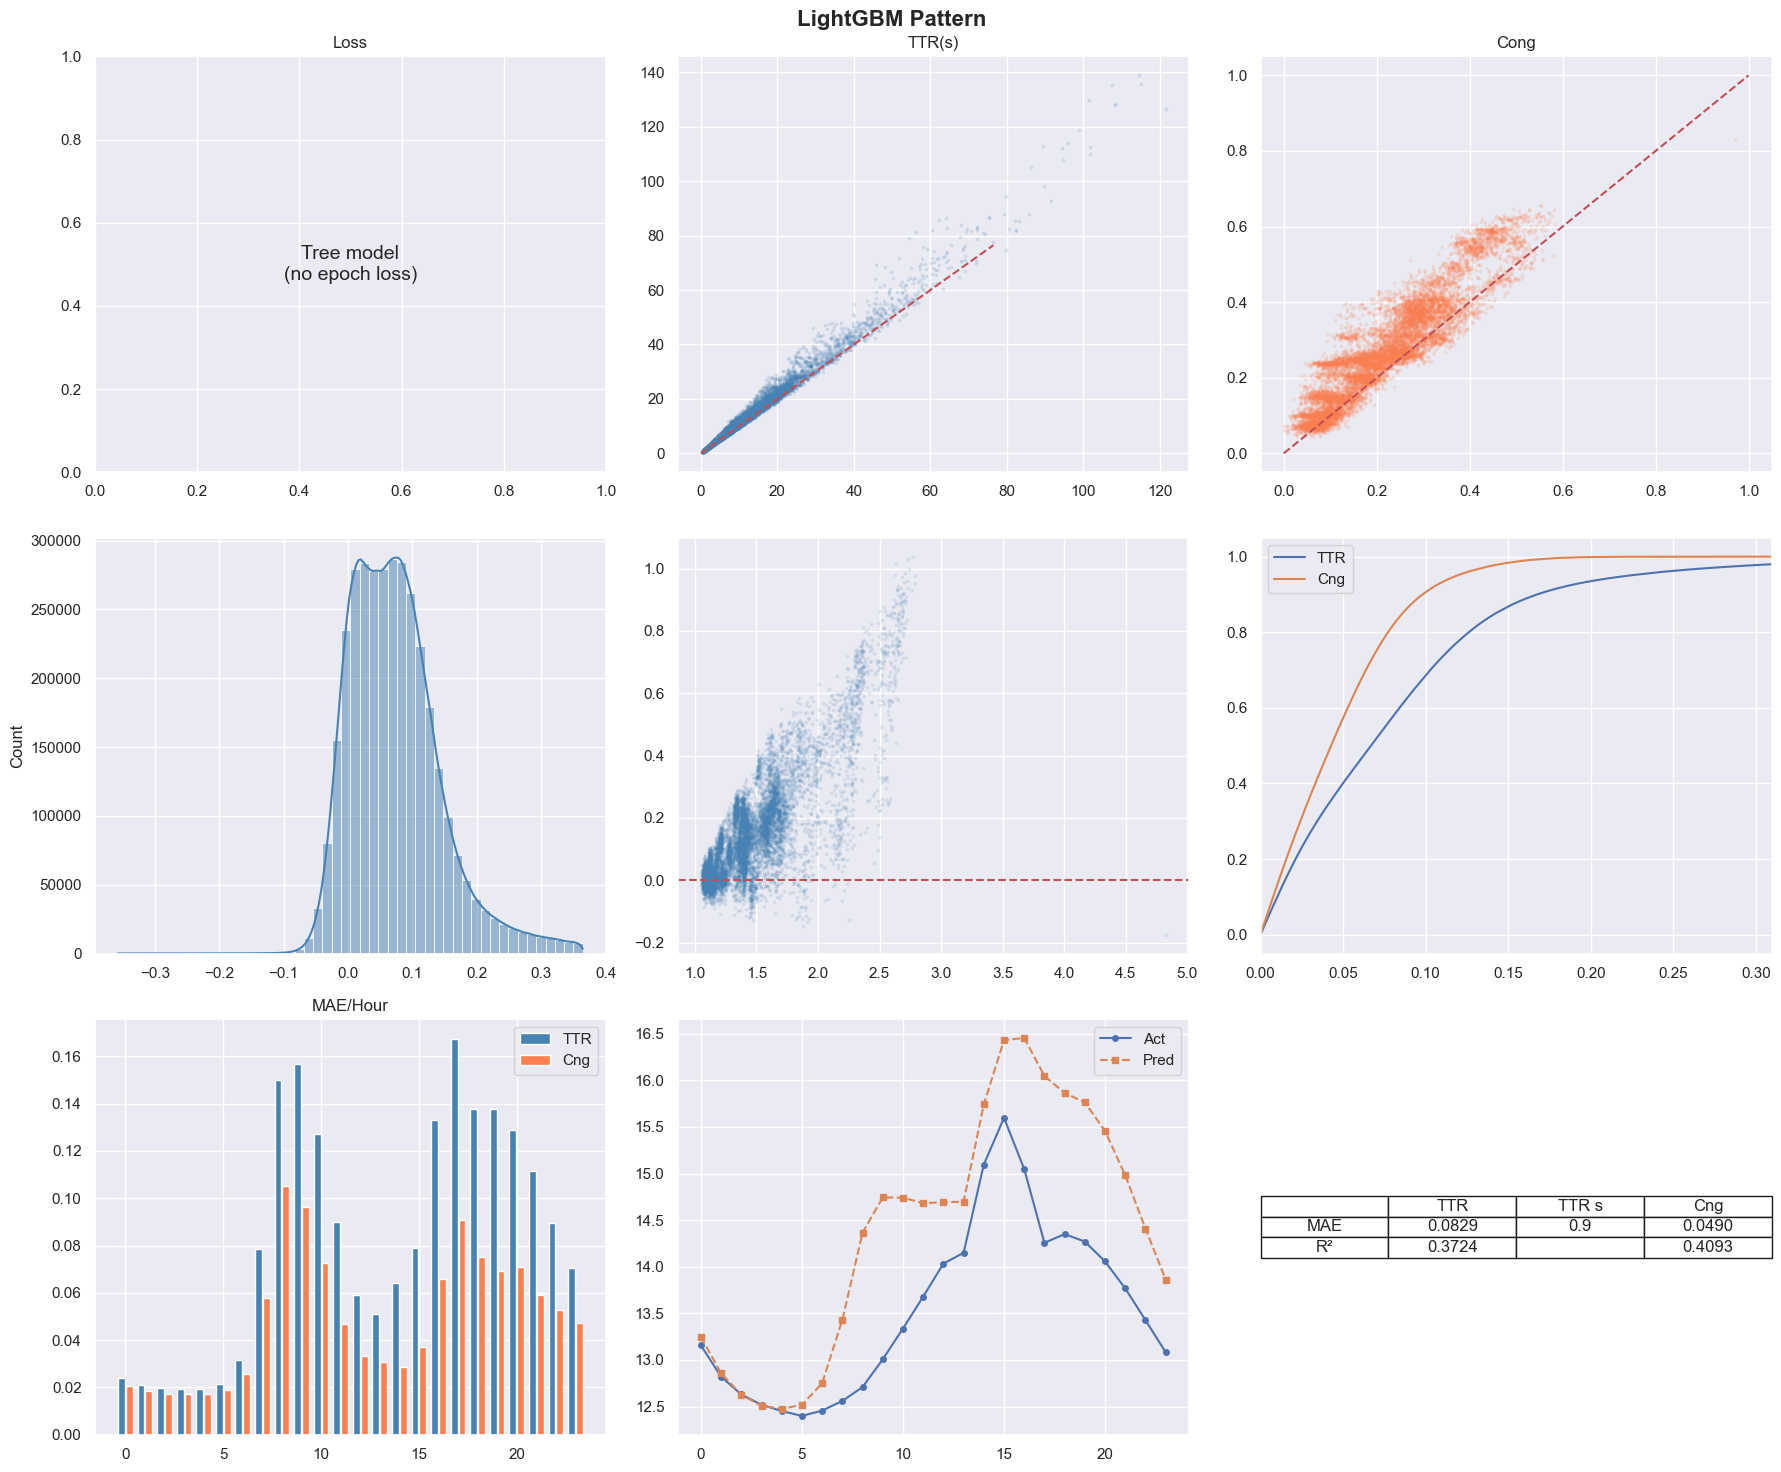

✓ LightGBM Pattern complete.


In [5]:
fig,axes=plt.subplots(3,3,figsize=(18,15)); fig.suptitle(f'{MODEL_DISPLAY}',fontsize=16,fontweight='bold')
ax=axes[0,0]; ax.text(.5,.5,'Tree model\n(no epoch loss)',ha='center',va='center',transform=ax.transAxes,fontsize=14); ax.set_title('Loss')
ns=min(10000,len(ttr_pred_sec)); ii=np.random.choice(ns,ns,replace=False)
ax=axes[0,1]; ax.scatter(ttr_act_sec[ii],ttr_pred_sec[ii],alpha=.12,s=3,c='steelblue'); ax.plot([0,np.percentile(ttr_act_sec,99)],[0,np.percentile(ttr_act_sec,99)],'r--'); ax.set_title('TTR(s)')
ax=axes[0,2]; ax.scatter(cong_act_inv[ii],cong_pred_inv[ii],alpha=.12,s=3,c='coral'); ax.plot([0,1],[0,1],'r--'); ax.set_title('Cong')
te=ttr_pred_inv-ttr_act_inv; ce=cong_pred_inv-cong_act_inv
ax=axes[1,0]; sns.histplot(te[np.abs(te)<np.percentile(np.abs(te),99)],kde=True,ax=ax,color='steelblue',bins=50)
ax=axes[1,1]; ax.scatter(ttr_pred_inv[ii],te[ii],alpha=.1,s=3,c='steelblue'); ax.axhline(0,c='r',ls='--')
ax=axes[1,2]; ta=np.sort(np.abs(te)); ca=np.sort(np.abs(ce)); ax.plot(ta,np.linspace(0,1,len(ta)),label='TTR'); ax.plot(ca,np.linspace(0,1,len(ca)),label='Cng'); ax.set_xlim(0,np.percentile(ta,98)); ax.legend()
th=sorted(set(hour_arr))
ax=axes[2,0]; ax.bar([h-.2 for h in th],[mean_absolute_error(ttr_act_inv[hour_arr==h],ttr_pred_inv[hour_arr==h]) for h in th],.35,label='TTR',color='steelblue')
ax.bar([h+.2 for h in th],[mean_absolute_error(cong_act_inv[hour_arr==h],cong_pred_inv[hour_arr==h]) for h in th],.35,label='Cng',color='coral'); ax.legend(); ax.set_title('MAE/Hour')
ax=axes[2,1]; ax.plot(th,[ttr_act_sec[hour_arr==h].mean() for h in th],'o-',label='Act',ms=4); ax.plot(th,[ttr_pred_sec[hour_arr==h].mean() for h in th],'s--',label='Pred',ms=4); ax.legend()
ax=axes[2,2]; ax.axis('off')
s=[['','TTR','TTR s','Cng'],['MAE',f'{mean_absolute_error(ttr_act_inv,ttr_pred_inv):.4f}',f'{mean_absolute_error(ttr_act_sec,ttr_pred_sec):.1f}',f'{mean_absolute_error(cong_act_inv,cong_pred_inv):.4f}'],
   ['R²',f'{r2_score(ttr_act_inv,ttr_pred_inv):.4f}','',f'{r2_score(cong_act_inv,cong_pred_inv):.4f}']]
ax.table(cellText=s[1:],colLabels=s[0],loc='center',cellLoc='center')
plt.tight_layout(); plt.savefig(f'{MODEL_DIR}/eval.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'✓ {MODEL_DISPLAY} complete.')